NAME : SANDESH NAKADE

CLASS : CSAI-D

ROLL NO : 34

PRN : 12412601

PROBLEM STATEMENT :Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following: a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis b. Bivariate analysis: Linear and logistic regression modeling c. Multiple Regression analysis d. Also compare the results of the above analysis for the two data sets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix


In [ ]:
df = pd.read_csv("heart_disease_dataset.csv")

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,39,1,1,102,123,0,1,194,0,0.31,1,1,2,0
1,55,1,3,142,154,0,0,149,0,0.45,0,0,1,0
2,29,1,1,100,146,0,0,185,0,0.89,2,0,3,0
3,65,0,1,103,182,0,1,176,1,0.18,1,0,1,0
4,75,1,2,124,136,1,0,147,0,0.27,0,1,1,1


In [ ]:
df['sex'].value_counts()



,count
sex,
1,537
0,463


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,53.101000,0.537000,1.454000,120.748000,203.368000,0.151000,0.622000,165.825000,0.511000,0.786290,0.929000,0.744000,1.773000,0.50000
std,13.861347,0.498879,1.127455,16.016648,51.031979,0.358228,0.667504,23.745025,0.500129,0.768389,0.687336,0.906248,0.867308,0.50025
min,29.000000,0.000000,0.000000,90.000000,120.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000
25%,42.000000,0.000000,0.000000,109.750000,166.000000,0.000000,0.000000,149.000000,0.000000,0.250000,0.000000,0.000000,1.000000,0.00000
50%,53.000000,1.000000,1.000000,120.000000,202.000000,0.000000,1.000000,166.000000,1.000000,0.540000,1.000000,0.000000,1.000000,0.50000
75%,65.000000,1.000000,2.000000,131.000000,238.000000,0.000000,1.000000,183.000000,1.000000,1.100000,1.000000,1.000000,3.000000,1.00000
max,77.000000,1.000000,3.000000,173.000000,369.000000,1.000000,2.000000,210.000000,1.000000,4.940000,2.000000,3.000000,3.000000,1.00000


In [ ]:
df.skew()


,0
age,-0.008310
sex,-0.148630
cp,0.053778
trestbps,0.169872
chol,0.231097
fbs,1.952384
restecg,0.609639
thalach,-0.114602
exang,-0.044077
oldpeak,1.795567


In [ ]:
df.kurt()

,0
age,-1.120297
sex,-1.981877
cp,-1.378974
trestbps,-0.294976
chol,-0.529107
fbs,1.815431
restecg,-0.679145
thalach,-0.556637
exang,-2.002065
oldpeak,4.050829


In [ ]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df["chol"] >= lower) & (df["chol"] <= upper)]


In [ ]:
# defining the featuree
X = df_clean[["age"]]
y = df_clean["chol"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [ ]:
print("----- Linear Regression Results -----")
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R-square:", r2)
print("Adjusted R-square:", adjusted_r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


----- Linear Regression Results -----
Intercept: 124.9884157337792
Coefficient: 1.4571677574562842
R-square: 0.11343299343658819
Adjusted R-square: 0.10895538229232848
MSE: 2132.336188595486
RMSE: 46.17722586508945
MAE: 38.04622645596366


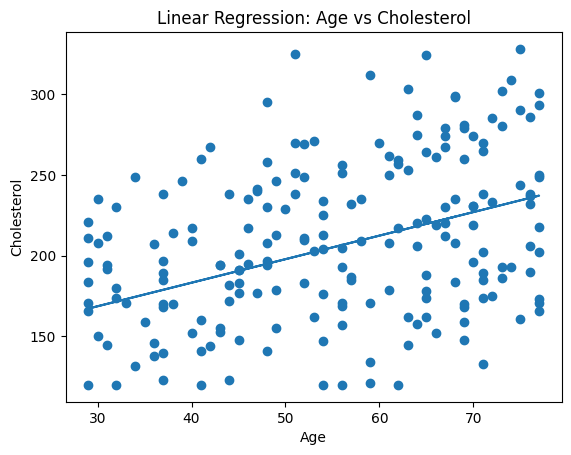

In [ ]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Linear Regression: Age vs Cholesterol")
plt.show()

LOGISTIC REGRESSION


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv("heart_disease_dataset.csv")
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   39    1   1       102   123    0        1      194      0     0.31      1   
1   55    1   3       142   154    0        0      149      0     0.45      0   
2   29    1   1       100   146    0        0      185      0     0.89      2   
3   65    0   1       103   182    0        1      176      1     0.18      1   
4   75    1   2       124   136    1        0      147      0     0.27      0   

   ca  thal  target  
0   1     2       0  
1   0     1       0  
2   0     3       0  
3   0     1       0  
4   1     1       1  


In [ ]:
X = df[['age']]     # Independent variable
y = df['target']    # Dependent variable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[62 38]
 [30 70]]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.66
Precision: 0.6481481481481481
Recall: 0.7
F1 Score: 0.6730769230769231


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


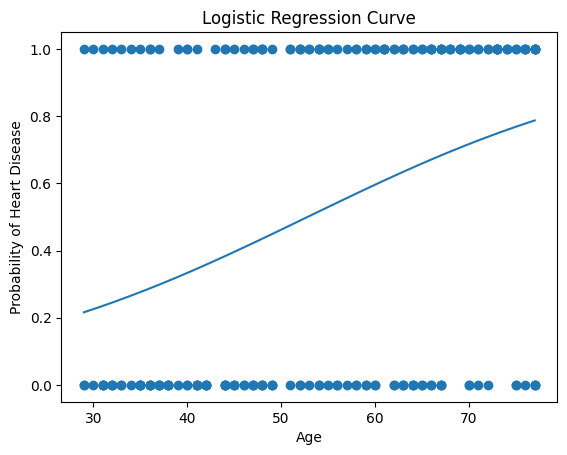

In [ ]:

X_range = np.linspace(X.min(), X.max(), 300).reshape(-1,1)
y_prob = model.predict_proba(X_range)[:,1]

plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_range, y_prob)
plt.xlabel("Age")
plt.ylabel("Probability of Heart Disease")
plt.title("Logistic Regression Curve")
plt.show()

In [ ]:
X = df[['age', 'chol', 'trestbps', 'thalach', 'exang']]
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[70 30]
 [31 69]]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Model Performance:
Accuracy: 0.695
Precision: 0.696969696969697
Recall: 0.69
F1 Score: 0.6934673366834171


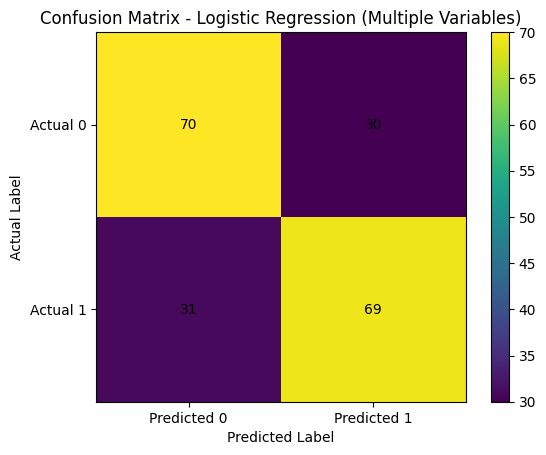

In [ ]:
plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression (Multiple Variables)")
plt.show()


MULTIPLE LINEAR REGRESSION


In [ ]:
X = df[['age', 'trestbps', 'thalach', 'oldpeak']]
y = df['chol']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 112.00394986634984
Coefficients: [1.56486069 0.03086782 0.02107155 1.55559805]


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R-square:", r2)
print("Adjusted R-square:", adjusted_r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

R-square: 0.037093501846470534
Adjusted R-square: 0.017341573679218625
MSE: 2261.5471977520046
RMSE: 47.55572728654252
MAE: 39.37992997591566


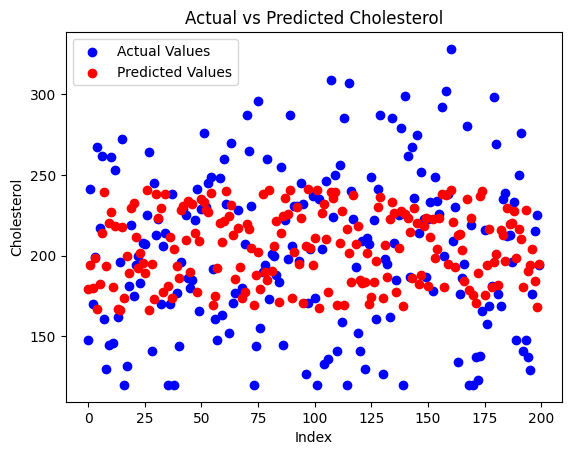

In [ ]:
plt.figure()

# Plot Actual values
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Values')

# Plot Predicted values
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted Values')

plt.xlabel("Index")
plt.ylabel("Cholesterol")
plt.title("Actual vs Predicted Cholesterol")
plt.legend()

plt.show()